In [3]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/cardio_dataset.csv')
print(df)

      SEX  AGEIR   TC  HDL  SMOKE_  BPMED  DIAB_01  RISK
0       1     48  236   66       0      1        0   1.1
1       0     48  260   51       0      1        1   7.0
2       0     44  187   49       1      1        0   7.0
3       1     42  216   57       1      1        0   0.4
4       1     56  156   42       0      1        0   2.2
...   ...    ...  ...  ...     ...    ...      ...   ...
6639    1     65  307   42       1      0        1  36.6
6640    1     42  169   56       0      0        0   0.8
6641    0     65  212   35       1      0        0  30.6
6642    0     66  184   39       0      0        0  23.8
6643    1     45  203   51       0      1        0   1.0

[6644 rows x 8 columns]


In [5]:
dataset=df.values
data=dataset[:,0:7]
target=dataset[:,7]

print(data.shape)
print(target.shape)


(6644, 7)
(6644,)


In [11]:
target=np.reshape(target,(-1,1))
print(target)

[[ 1.1]
 [ 7. ]
 [ 7. ]
 ...
 [30.6]
 [23.8]
 [ 1. ]]


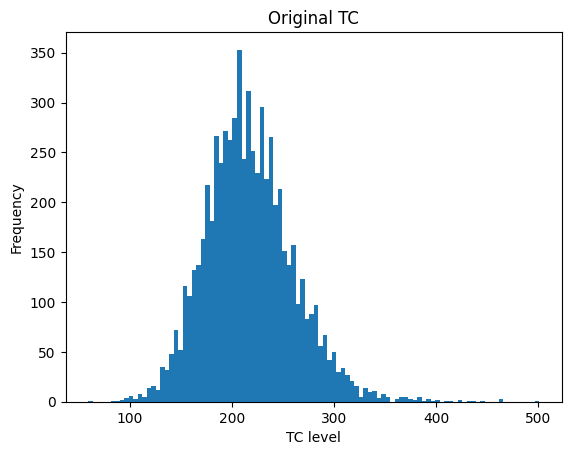

In [19]:
from matplotlib import pyplot as plt
plt.hist(data[:,2],bins=100)
plt.title('Original TC')
plt.xlabel('TC level')
plt.ylabel('Frequency')
plt.show()

# Data preprocessing

In [12]:
import numpy as np

from sklearn.preprocessing import MinMaxScaler
target=np.reshape(target,(-1,1))

scaler_data=MinMaxScaler()
scaler_target=MinMaxScaler()

scaler_data.fit(data)
scaler_target.fit(target)

data_scaled=scaler_data.transform(data)
target_scaled=scaler_target.transform(target)

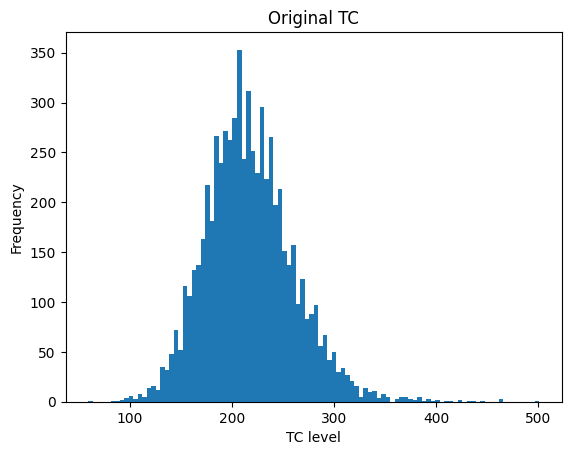

In [13]:
from matplotlib import pyplot as plt
plt.hist(data[:,2],bins=100)
plt.title('Original TC')
plt.xlabel('TC level')
plt.ylabel('Frequency')
plt.show()

In [17]:
print(data[:10])

[[  1.  48. 236.  66.   0.   1.   0.]
 [  0.  48. 260.  51.   0.   1.   1.]
 [  0.  44. 187.  49.   1.   1.   0.]
 [  1.  42. 216.  57.   1.   1.   0.]
 [  1.  56. 156.  42.   0.   1.   0.]
 [  0.  44. 162.  57.   1.   1.   0.]
 [  0.  50. 244.  47.   0.   1.   0.]
 [  0.  48. 212.  30.   1.   1.   0.]
 [  1.  66. 202.  53.   0.   1.   1.]
 [  0.  63. 186.  46.   1.   1.   0.]]


In [18]:
print(data_scaled)

[[1.         0.20512821 0.40045249 ... 0.         1.         0.        ]
 [0.         0.20512821 0.45475113 ... 0.         1.         1.        ]
 [0.         0.1025641  0.28959276 ... 1.         1.         0.        ]
 ...
 [0.         0.64102564 0.34615385 ... 1.         0.         0.        ]
 [0.         0.66666667 0.28280543 ... 0.         0.         0.        ]
 [1.         0.12820513 0.32579186 ... 0.         1.         0.        ]]


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data_scaled,target_scaled,test_size=0.2)


In [39]:
import keras.models as models
import keras.layers as layers
from keras.layers import Dropout
import numpy as np

model=models.Sequential()
model.add(layers.Dense(96,input_dim=7,activation='relu'))
model.add(Dropout(0.4))
model.add(layers.Dense(48,activation='relu'))
model.add(Dropout(0.3))
model.add(layers.Dense(24,activation='relu'))
model.add(layers.Dense(1,activation='linear'))
model.compile(optimizer='adam',loss='mse',metrics=['mae','mse'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 96)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,625 (25.88 KB)

 Trainable params: 6,625 (25.88 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history=model.fit(x_train,y_train,epochs=200,validation_data=(x_test,y_test))

Epoch 1/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0198 - mae: 0.0992 - mse: 0.0198 - val_loss: 0.0084 - val_mae: 0.0540 - val_mse: 0.0084
Epoch 2/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0094 - mae: 0.0671 - mse: 0.0094 - val_loss: 0.0053 - val_mae: 0.0418 - val_mse: 0.0053
Epoch 3/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074 - mae: 0.0575 - mse: 0.0074 - val_loss: 0.0062 - val_mae: 0.0455 - val_mse: 0.0062
Epoch 4/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063 - mae: 0.0523 - mse: 0.0063 - val_loss: 0.0058 - val_mae: 0.0439 - val_mse: 0.0058
Epoch 5/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - mae: 0.0513 - mse: 0.0062 - val_loss: 0.0056 - val_mae: 0.0434 - val_mse: 0.0056
Epoch 6/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0057 - mae: 0.0490 - mse: 0.0057 - val_loss: 0.0061 - val_mae: 0.0459 - val_mse: 0.0061
Epoch 7/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - mae: 0.0472 - mse: 0.005

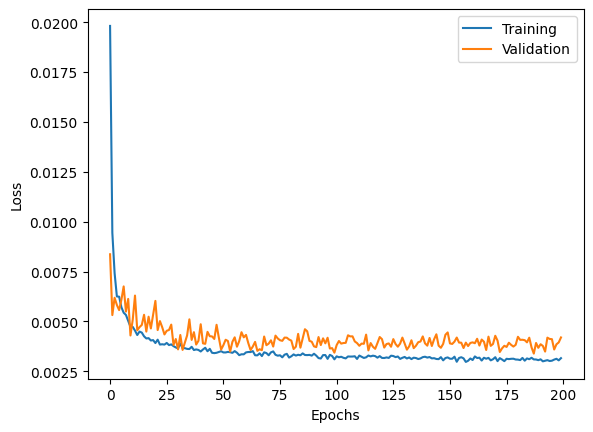

In [41]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training','Validation'])
plt.show()

In [42]:
from sklearn.metrics import r2_score
predicted_result=model.predict(x_test)
r2=r2_score(y_test,predicted_result)
print('r2 score is',r2)


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
r2 score is 0.809783811994862


In [43]:
print('Actual:',y_test[:10].T)
print('Predicted:',predicted_result[:10].T)

Actual: [[0.00234467 0.42321219 0.14185229 0.01992966 0.00586166 0.00468933
  0.03048066 0.02696366 0.03516999 0.05392732]]
Predicted: [[0.02046011 0.2982955  0.18336347 0.03135464 0.03356206 0.02140936
  0.06746422 0.07204739 0.10158015 0.11893594]]


In [44]:
print('Actual inverse scaled :',scaler_target.inverse_transform(y_test[:10].T))
print('Predicted inverse scaled :',scaler_target.inverse_transform(predicted_result[:10].T))

Actual inverse scaled : [[ 0.3 36.2 12.2  1.8  0.6  0.5  2.7  2.4  3.1  4.7]]
Predicted inverse scaled : [[ 1.8452476 25.544605  15.740904   2.7745504  2.9628441  1.9262185
   5.8546977  6.2456427  8.764787  10.245236 ]]


In [33]:
my_test_data=[1,56,156,42,0,1,0]
my_test_data=scaler_data.transform([my_test_data])

result=model.predict(my_test_data)
actual=7
predicted=scaler_target.inverse_transform(result)
print('Actual TC:',actual)
print('Predicted TC:',result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Actual TC: 7
Predicted TC: [[0.04418503]]


In [45]:
model.save('Classification regression NN.keras')